# Pre-processing and Integration of scRNA_seq datasets

## Pre-processing of 10x Multiome Data 

In [2]:
## Load packages
library(Seurat)
library(Signac)
library(hdf5r)
library(EnsDb.Hsapiens.v86)
library(dplyr)
library(data.table)
library(ggplot2)
options(repr.plot.width=12, repr.plot.height=10)

### Setup the Seurat objects for each aggregated tissue library
- Extract RNA and ATAC data from 10x output
- Set up seruat objects and attach ATAC-seq data 
- Keep ATAC-seq peaks in standard chromosomes 

In [ ]:
# the 10x hdf5 file contains both data types. 
inputdata.10x <- Read10X_h5("AGG_lungs/filtered_feature_bc_matrix.h5")

# extract RNA and ATAC data
rna_counts <- inputdata.10x$`Gene Expression`
atac_counts <- inputdata.10x$Peaks

# Create Seurat object
lung <- CreateSeuratObject(counts = rna_counts)
lung[["percent.mt"]] <- PercentageFeatureSet(spleen, pattern = "^MT-")

# Now add in the ATAC-seq data
# we'll only use peaks in standard chromosomes
grange.counts <- StringToGRanges(rownames(atac_counts), sep = c(":", "-"))
grange.use <- seqnames(grange.counts) %in% standardChromosomes(grange.counts)
atac_counts <- atac_counts[as.vector(grange.use), ]
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
seqlevelsStyle(annotations) <- 'UCSC'
genome(annotations) <- "hg38"

frag.file <- "AGG_lungs/atac_fragments.tsv.gz"
chrom_assay <- CreateChromatinAssay(
   sep = c(":", "-"),
   genome = 'hg38',
   fragments = frag.file,
   min.cells = 10,
   annotation = annotations
 )
lung[["ATAC"]] <- chrom_assay
lung@meta.data[,"orig.ident"]<-unlist(lapply(rownames(lung@meta.data), function(i){strsplit(i, "-")[[1]][2]}))

In [ ]:
# the 10x hdf5 file contains both data types. 
inputdata.10x <- Read10X_h5("AGG_spleens/filtered_feature_bc_matrix.h5")

# extract RNA and ATAC data
rna_counts <- inputdata.10x$`Gene Expression`
atac_counts <- inputdata.10x$Peaks

# Create Seurat object
spleen <- CreateSeuratObject(counts = rna_counts)
spleen[["percent.mt"]] <- PercentageFeatureSet(spleen, pattern = "^MT-")

# Now add in the ATAC-seq data
# we'll only use peaks in standard chromosomes
grange.counts <- StringToGRanges(rownames(atac_counts), sep = c(":", "-"))
grange.use <- seqnames(grange.counts) %in% standardChromosomes(grange.counts)
atac_counts <- atac_counts[as.vector(grange.use), ]
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
seqlevelsStyle(annotations) <- 'UCSC'
genome(annotations) <- "hg38"

frag.file <- "AGG_spleens/atac_fragments.tsv.gz"
chrom_assay <- CreateChromatinAssay(
   counts = atac_counts,
   sep = c(":", "-"),
   genome = 'hg38',
   fragments = frag.file,
   min.cells = 10,
   annotation = annotations
 )
spleen[["ATAC"]] <- chrom_assay
spleen@meta.data[,"orig.ident"]<-unlist(lapply(rownames(spleen@meta.data), function(i){strsplit(i, "-")[[1]][2]}))

### Run standard analysis pipeline from Seurat

In [34]:
## Filter cells that do not satisfy the following criteria
lung <- subset(
  x = lung,
  subset = nCount_ATAC < 8e4 &
    nCount_ATAC > 5e2 &
    nCount_RNA < 25000 &
    nCount_RNA > 250 &
    percent.mt < 10
)

In [44]:
## Filter cells that do not satisfy the following criteria
spleen <- subset(
  x = spleen,
  subset = nCount_ATAC < 8e4 &
    nCount_ATAC > 5e2 &
    nFeature_RNA < 4000 &
    nFeature_RNA > 250 &
    percent.mt < 10
)

In [1]:
## Visualize count distribution
VlnPlot(lung, features = c("nCount_ATAC", "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend()

plot1 <- FeatureScatter(lung, feature1 = "nCount_RNA", feature2 = "percent.mt") 
plot2 <- FeatureScatter(lung, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + NoLegend() + plot2 + NoLegend()

In [ ]:
## Visualize count distribution
VlnPlot(spleen, features = c("nCount_ATAC", "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend()

plot1 <- FeatureScatter(lung, feature1 = "nCount_RNA", feature2 = "percent.mt") 
plot2 <- FeatureScatter(lung, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")


## Perform integration

### Within-tissue integration

In [ ]:
## Integrate multiple lung samples
lung.list <- SplitObject(lung, split.by = "orig.ident")
lung.list <- lapply(X = lung.list, FUN = function(x) {
    x <- NormalizeData(x, verbose = FALSE)
    x <- FindVariableFeatures(x, verbose = FALSE)
})

features <- SelectIntegrationFeatures(object.list = lung.list)
lung.list <- lapply(X = lung.list, FUN = function(x) {
    x <- ScaleData(x, features = features, verbose = FALSE)
    x <- RunPCA(x, features = features, verbose = FALSE)
})

anchors <- FindIntegrationAnchors(object.list = lung.list, reference = c(1, 2), reduction = "rpca",
    dims = 1:20)
lung.integrated <- IntegrateData(anchorset = anchors, dims = 1:20)

lung.integrated <- ScaleData(lung.integrated, verbose = FALSE)
lung.integrated <- RunPCA(lung.integrated, verbose = FALSE)
lung.integrated <- RunUMAP(lung.integrated, dims = 1:20)

lung.integrated <- FindNeighbors(lung.integrated, reduction = "pca", dims = 1:20)
lung.integrated <- FindClusters(lung.integrated, resolution = 0.5)


In [ ]:
## Integrate multiple spleen samples
spleen.list <- SplitObject(spleen, split.by = "orig.ident")
spleen.list <- lapply(X = spleen.list, FUN = function(x) {
    x <- NormalizeData(x, verbose = FALSE)
    x <- FindVariableFeatures(x, verbose = FALSE)
})

features <- SelectIntegrationFeatures(object.list = spleen.list)
spleen.list <- lapply(X = spleen.list, FUN = function(x) {
    x <- ScaleData(x, features = features, verbose = FALSE)
    x <- RunPCA(x, features = features, verbose = FALSE)
})

anchors <- FindIntegrationAnchors(object.list = spleen.list, reference = c(1, 2), reduction = "rpca",
    dims = 1:20)
spleen.integrated <- IntegrateData(anchorset = anchors, dims = 1:20)

spleen.integrated <- ScaleData(spleen.integrated, verbose = FALSE)
spleen.integrated <- RunPCA(spleen.integrated, verbose = FALSE)
spleen.integrated <- RunUMAP(spleen.integrated, dims = 1:20)

spleen.integrated <- FindNeighbors(spleen.integrated, reduction = "pca", dims = 1:20)
spleen.integrated <- FindClusters(spleen.integrated, resolution = 0.5)


### Cross-tissue integration

In [12]:
features <- SelectIntegrationFeatures(object.list = list(lung.integrated, spleen.integrated))

immune.anchors <- FindIntegrationAnchors(object.list = list(lung.integrated, spleen.integrated), 
                                         anchor.features = features, reduction = "rpca")

immune.combined <- IntegrateData(anchorset = immune.anchors)

In [11]:
# specify that we will perform downstream analysis on the corrected data note that the
# original unmodified data still resides in the 'RNA' assay
DefaultAssay(immune.combined) <- "integrated"

# Run the standard workflow for visualization and clustering
immune.combined <- ScaleData(immune.combined, verbose = FALSE)
immune.combined <- RunPCA(immune.combined, npcs = 30, verbose = FALSE)
immune.combined <- RunUMAP(immune.combined, reduction = "pca", dims = 1:30)
immune.combined <- FindNeighbors(immune.combined, reduction = "pca", dims = 1:30)
immune.combined <- FindClusters(immune.combined, resolution = 0.5)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:46:37 UMAP embedding parameters a = 0.9922 b = 1.112

10:46:37 Read 53647 rows and found 30 numeric columns

10:46:37 Using Annoy for neighbor search, n_neighbors = 30

10:46:37 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:46:44 Writing NN index file to temp file /tmp/jobs/25772033/RtmpK5R56q/file41e077e4bee8

10:46:44 Searching Annoy index using 1 thread, search_k = 3000

10:47:08 Annoy recall = 100%

10:47:09 Commencing smooth kNN distance calibration using 1 thread
 with targe

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 53647
Number of edges: 1811748

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9042
Number of communities: 16
Elapsed time: 27 seconds


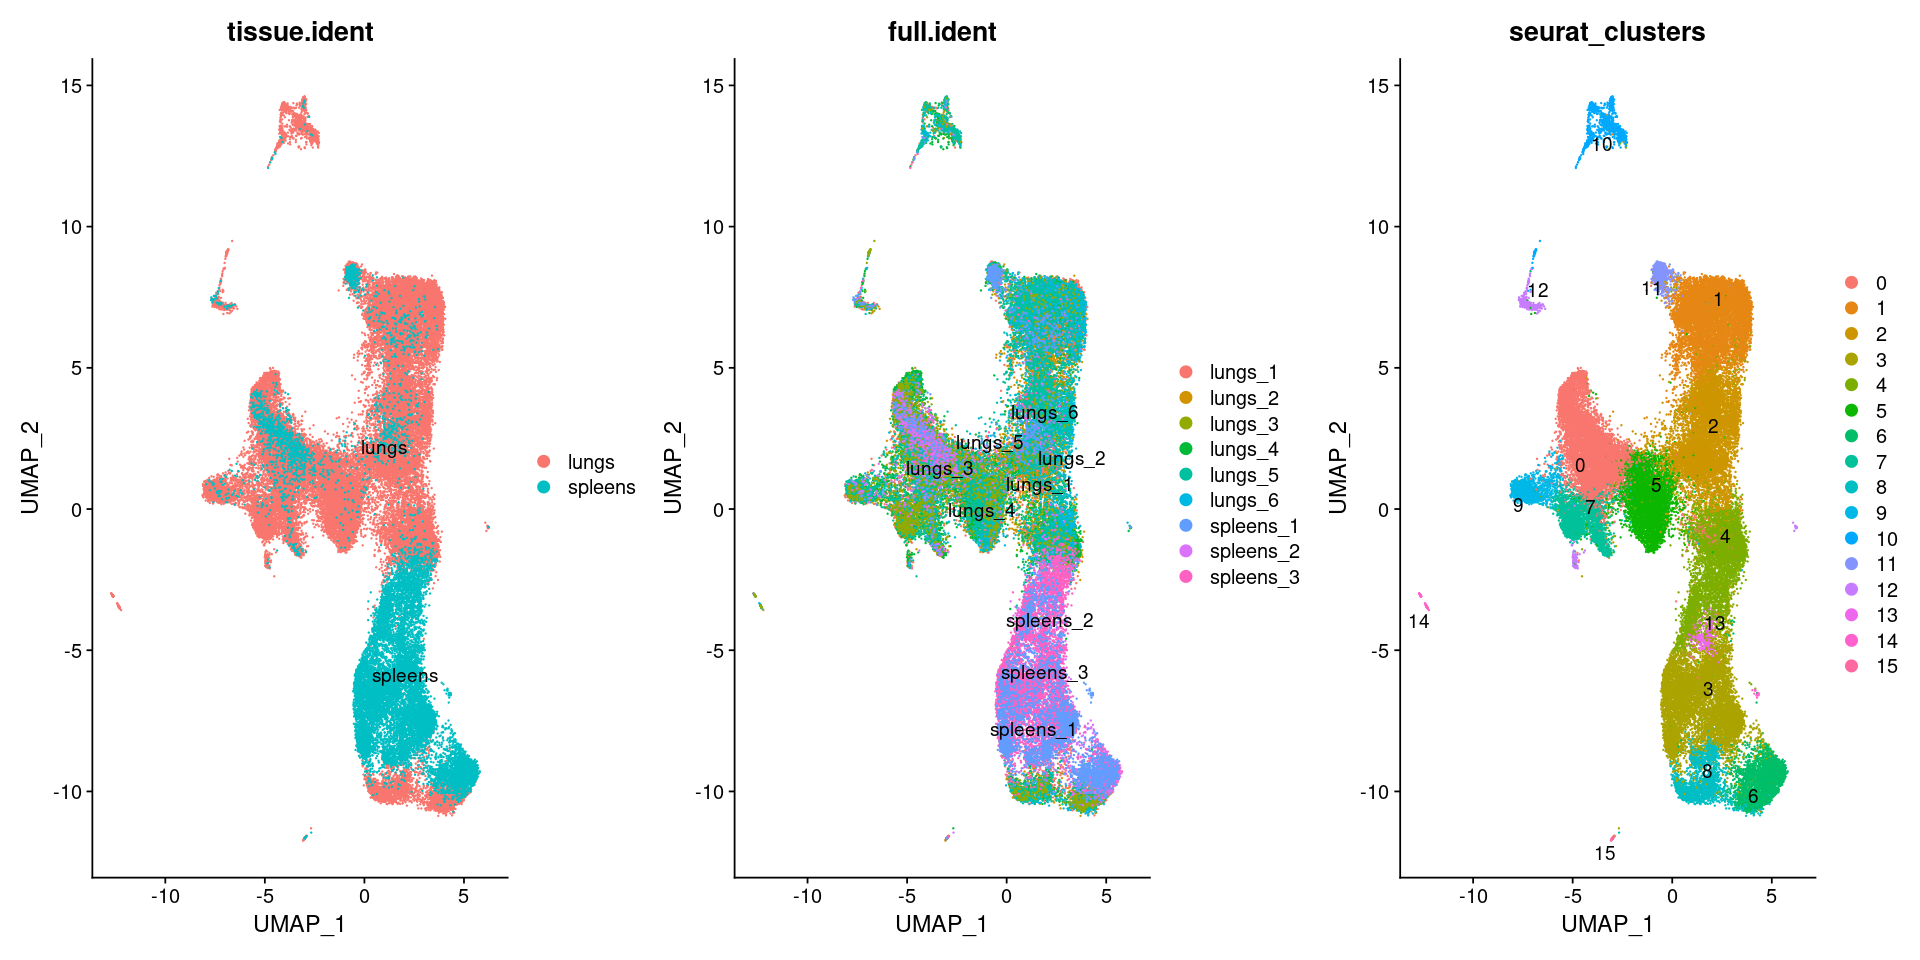

In [25]:
## Visualize integrated data with UMAP
p1 <- DimPlot(immune.combined, reduction = "umap", group.by = "tissue.ident", label=TRUE, repel = TRUE)
p2 <- DimPlot(immune.combined, reduction = "umap", group.by = "full.ident", label = TRUE,
    repel = TRUE)
p1 + p2 

In [ ]:
## Save Seurat object into a h5Dad object that can be read by scanpy package
DefaultAssay(immune.combined)<-"RNA"

library("SeuratDisk")
SaveH5Seurat(immune.combined, 
             filename = "lungs_spleens_merged_scRNA_only.h5Seurat")
Convert("lungs_spleens_merged_scRNA_only.h5Seurat", dest = "h5ad")

## Annotate cell clusters with CellTypist

In [ ]:
# Python code
## Load package
!pip install celltypist
import celltypist
from celltypist import models
import scanpy as sc

## Read our integrated data
adata = sc.read('lungs_spleens_merged_scRNA_only.h5ad')
## Enable `force_update = True` will overwrite existing (old) models.
models.download_models(force_update = True)
## Make predictions
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)